In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.datasets import fetch_california_housing
import warnings
warnings.filterwarnings('ignore')

# 1. 加载加州房价数据集
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = california.target

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 特征 Z-score 标准化（正则化模型必须步骤）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
feature_names = X.columns

用Ridge和Lasso建模

In [88]:
# 1. alpha 搜索范围
ridge_alphas = np.logspace(-1, 3, 200)
lasso_alphas = np.logspace(-4, 2, 200)

# 2. 训练模型
ridge = RidgeCV(alphas=ridge_alphas, store_cv_values=True)
ridge.fit(X_train_scaled, y_train)

lasso = LassoCV(alphas=lasso_alphas, cv=10, random_state=42, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

# 3. Ridge 1-SE
ridge_mse = ridge.cv_values_.mean(axis=0)
ridge_se = ridge.cv_values_.std(axis=0) / np.sqrt(ridge.cv_values_.shape[0])
ridge_threshold = ridge_mse.min() + ridge_se[ridge_mse.argmin()]
ridge_1se = ridge_alphas[ridge_mse <= ridge_threshold][-1]

# 4. Lasso 1-SE
lasso_mse = np.mean(lasso.mse_path_, axis=1)
lasso_se = np.std(lasso.mse_path_, axis=1) / np.sqrt(10)
lasso_threshold = lasso_mse.min() + lasso_se[lasso_mse.argmin()]

valid_idx = np.where(lasso_mse <= lasso_threshold)[0]

lasso_1se = lasso_alphas[valid_idx[0]]  # 默认最安全的值
for idx in reversed(valid_idx):
    # 关键：传只包含单个 alpha 的列表给 LassoCV 进行拟合
    temp_model = LassoCV(alphas=[lasso_alphas[idx]], cv=10, random_state=42, max_iter=10000)
    temp_model.fit(X_train_scaled, y_train)
    # 判断非零系数个数（绝对值大于 1e-5 视为非零）
    if np.sum(np.abs(temp_model.coef_) > 1e-5) >= 1:
        lasso_1se = lasso_alphas[idx]
        break

print(f"Ridge: best alpha={ridge.alpha_:.4f} | 1-SE alpha={ridge_1se:.4f}")
print(f"Lasso: best alpha={lasso.alpha_:.4f} | 1-SE alpha={lasso_1se:.4f}")

Ridge: best alpha=2.1215 | 1-SE alpha=415.0405
Lasso: best alpha=0.0009 | 1-SE alpha=0.7753


系数路径图

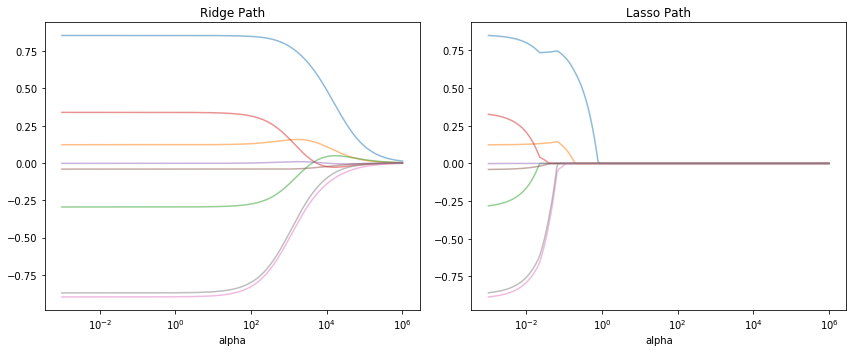

In [89]:
# 记录不同 alpha 下的系数变化，用于绘制路径图
r_coef = []
l_coef = []
for a in alphas:
    r_coef.append(Ridge(alpha=a).fit(X_train_scaled, y_train).coef_)
    l_coef.append(LassoCV(alphas=[a], random_state=42).fit(X_train_scaled, y_train).coef_)

r_coef = np.array(r_coef)
l_coef = np.array(l_coef)

# 绘制路径图
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for i in range(r_coef.shape[1]):
    plt.plot(alphas, r_coef[:, i], alpha=0.5)
plt.xscale('log')
plt.title("Ridge Path")
plt.xlabel("alpha")

plt.subplot(1, 2, 2)
for i in range(l_coef.shape[1]):
    plt.plot(alphas, l_coef[:, i], alpha=0.5)
plt.xscale('log')
plt.title("Lasso Path")
plt.xlabel("alpha")

plt.tight_layout()
plt.show()

测试集 RMSE 与非零变量数报告

In [90]:
# 在测试集上评估模型的 RMSE 和非零特征数（稀疏度）
r_pred = ridge.predict(X_test_scaled)
l_pred = lasso.predict(X_test_scaled)

print(f"{'Model':<8} | {'Test RMSE':<10} | {'Non-zero Coefs'}")
print("-" * 40)
print(f"{'Ridge':<8} | {np.sqrt(mean_squared_error(y_test, r_pred)):<10.3f} | {np.sum(ridge.coef_ != 0)}")
print(f"{'Lasso':<8} | {np.sqrt(mean_squared_error(y_test, l_pred)):<10.3f} | {np.sum(lasso.coef_ != 0)}")

# 评估 1-SE 法则选择出的 Lasso 模型
lasso_1se_model = LassoCV(alphas=[lasso_1se], random_state=42).fit(X_train_scaled, y_train)
l1se_pred = lasso_1se_model.predict(X_test_scaled)
print(f"{'Lasso 1-SE':<8} | {np.sqrt(mean_squared_error(y_test, l1se_pred)):<10.3f} | {np.sum(lasso_1se_model.coef_ != 0)}")

Model    | Test RMSE  | Non-zero Coefs
----------------------------------------
Ridge    | 0.746      | 8
Lasso    | 0.745      | 8
Lasso 1-SE | 1.129      | 1
